This notebook explores the eda_medicare_part_d data.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/raw/Medicare Part D Prescribers - by Geography and Drug/"
    "Medicare Part D Prescribers - by Geography and Drug/"
    "2023/MUP_DPR_RY25_P04_V10_DY23_Geo.csv"
)

df.shape

C:\Users\alybo\AppData\Local\Temp\ipykernel_48976\3195148426.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


(115936, 22)

In [5]:
df.head()
df.columns
df.dtypes
df.describe()
df.isna().sum().sort_values(ascending=False)

GE65_Sprsn_Flag         94873
GE65_Bene_Sprsn_Flag    67088
GE65_Tot_Benes          48848
Tot_Benes               21596
GE65_Tot_Clms           21063
GE65_Tot_30day_Fills    21063
GE65_Tot_Drug_Cst       21063
Prscrbr_Geo_Cd           3608
Prscrbr_Geo_Desc            1
Antbtc_Drug_Flag            0
Opioid_LA_Drug_Flag         0
Opioid_Drug_Flag            0
NonLIS_Bene_Cst_Shr         0
LIS_Bene_Cst_Shr            0
Prscrbr_Geo_Lvl             0
Tot_Drug_Cst                0
Tot_30day_Fills             0
Tot_Clms                    0
Tot_Prscrbrs                0
Gnrc_Name                   0
Brnd_Name                   0
Antpsyct_Drug_Flag          0
dtype: int64

In [14]:
df.describe()

,Tot_Prscrbrs,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Benes,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Benes,LIS_Bene_Cst_Shr,NonLIS_Bene_Cst_Shr,GE65_ratio
count,115936.000000,1.159360e+05,1.159360e+05,1.159360e+05,9.434000e+04,9.487300e+04,9.487300e+04,9.487300e+04,6.708800e+04,1.159360e+05,1.159360e+05,94873.000000
mean,1633.927667,2.789245e+04,5.087556e+04,4.753530e+06,1.030317e+04,2.822537e+04,5.346846e+04,4.423261e+06,1.238629e+04,1.167093e+04,3.127506e+05,0.696029
std,14917.992926,4.702736e+05,1.019406e+06,8.787711e+07,1.412452e+05,4.508361e+05,1.011888e+06,8.345800e+07,1.475074e+05,1.765071e+05,6.623784e+06,0.266279
min,1.000000,1.100000e+01,1.100000e+01,1.506000e+01,1.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,14.000000,5.100000e+01,6.870000e+01,1.791928e+04,3.800000e+01,6.100000e+01,8.050000e+01,1.969902e+04,7.800000e+01,2.155000e+01,1.113705e+03,0.572403
50%,62.000000,2.830000e+02,3.863000e+02,1.291858e+05,1.690000e+02,3.820000e+02,5.229000e+02,1.345428e+05,3.590000e+02,1.860150e+02,8.818410e+03,0.778814
75%,427.000000,2.503000e+03,3.623925e+03,8.348181e+05,1.284000e+03,3.074000e+03,4.619300e+03,7.773636e+05,2.212250e+03,1.938015e+03,6.111388e+04,0.888598
max,725303.000000,6.846728e+07,1.679827e+08,1.826613e+10,1.677038e+07,6.090046e+07,1.521763e+08,1.716443e+10,1.509227e+07,3.274342e+07,1.712191e+09,1.000000


This dataset is dominated by:

Many small prescriber–drug–geography combinations and a few massive high-volume entries

That kind of skew often indicates:

Market concentration, policy sensitivity, possibly outlier institutions, or very common generic drugs

Distribution of total claims

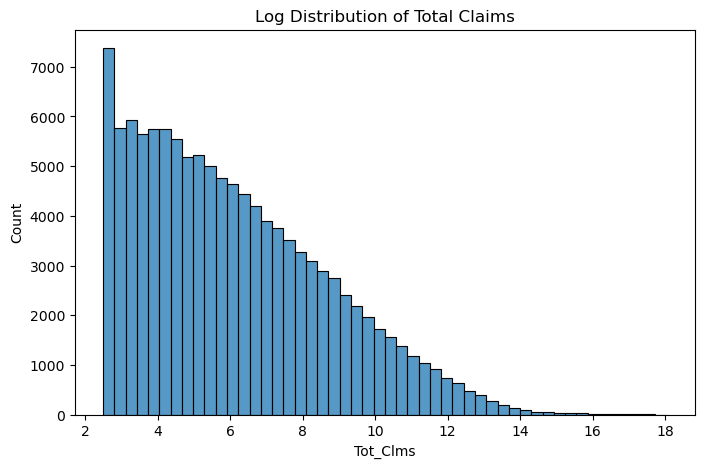

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["Tot_Clms"]), bins=50)
plt.title("Log Distribution of Total Claims")
plt.show()

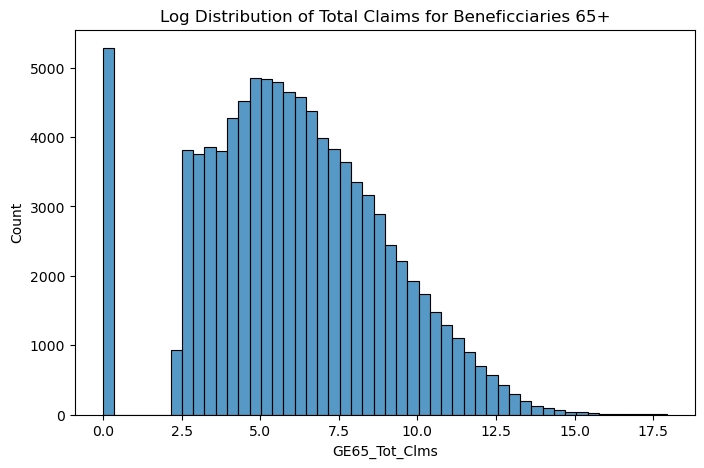

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["GE65_Tot_Clms"]), bins=50)
plt.title("Log Distribution of Total Claims for Beneficciaries 65+")
plt.show()

In [11]:
df["GE65_ratio"] = df["GE65_Tot_Clms"] / df["Tot_Clms"]

df["GE65_ratio"].describe()

count    94873.000000
mean         0.696029
std          0.266279
min          0.000000
25%          0.572403
50%          0.778814
75%          0.888598
max          1.000000
Name: GE65_ratio, dtype: float64

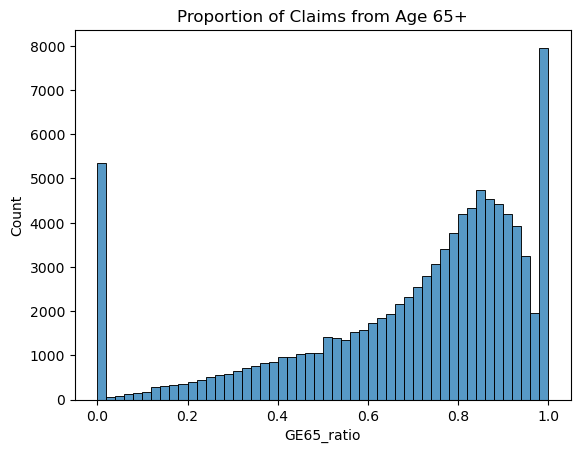

In [12]:
sns.histplot(df["GE65_ratio"], bins=50)
plt.title("Proportion of Claims from Age 65+")
plt.show()

Distribution of total drug cost

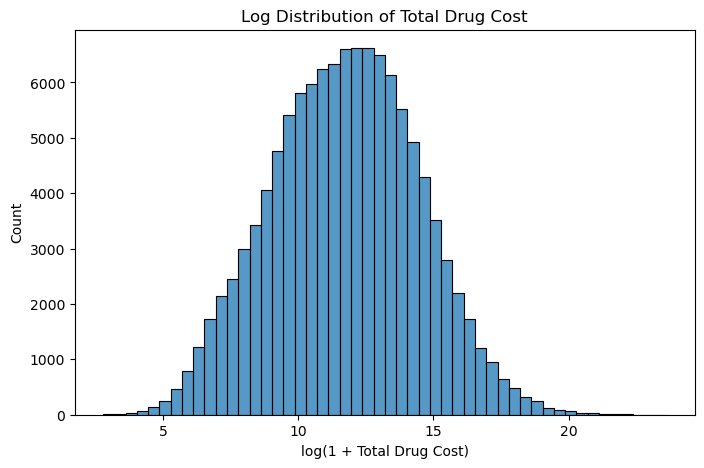

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["Tot_Drug_Cst"]), bins=50)
plt.title("Log Distribution of Total Drug Cost")
plt.xlabel("log(1 + Total Drug Cost)")
plt.show()

Based on this nice bell curve we can use linear regression on log(cost) using [Tot_Clms, Tot_Benes, LIS share, GE65 proportion, Geography, Drug flags (opioid, antibiotic, antipsychotic)] when we create our model

Let's analyze cost per claim:

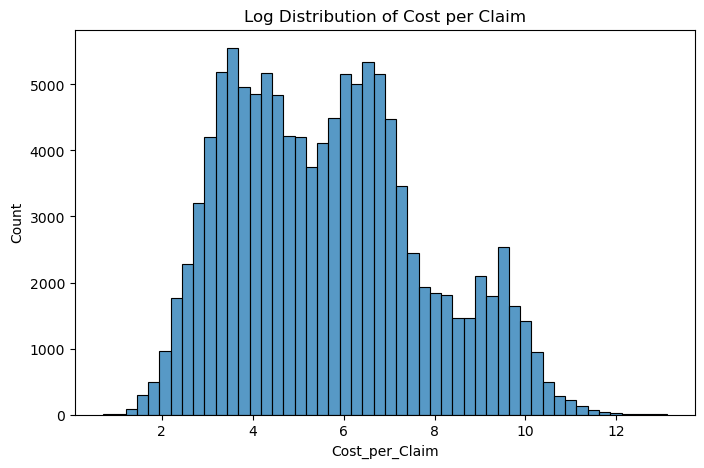

In [21]:
df["Cost_per_Claim"] = df["Tot_Drug_Cst"] / df["Tot_Clms"]

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["Cost_per_Claim"]), bins=50)
plt.title("Log Distribution of Cost per Claim")
plt.show()

In [22]:
df["Tot_Drug_Cst"].quantile([0.5, 0.9, 0.99, 0.999])

0.500    1.291858e+05
0.900    3.976876e+06
0.990    6.635024e+07
0.999    5.436605e+08
Name: Tot_Drug_Cst, dtype: float64

This shows Spending is extremely concentrated among a small number of high-cost drug entries like 

Specialty drugs

Oncology

Biologics

Rare disease treatments

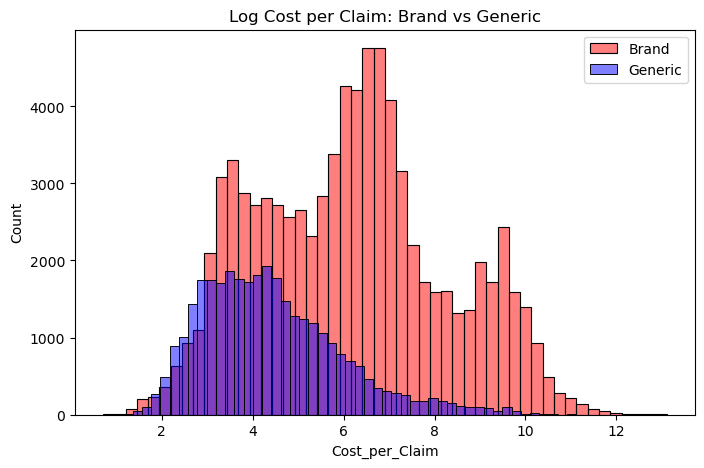

In [23]:
df["Cost_per_Claim"] = df["Tot_Drug_Cst"] / df["Tot_Clms"]
df["Is_Brand"] = df["Brnd_Name"] != df["Gnrc_Name"]

plt.figure(figsize=(8,5))
sns.histplot(
    np.log1p(df[df["Is_Brand"]]["Cost_per_Claim"]),
    color="red",
    label="Brand",
    bins=50,
    alpha=0.5
)

sns.histplot(
    np.log1p(df[~df["Is_Brand"]]["Cost_per_Claim"]),
    color="blue",
    label="Generic",
    bins=50,
    alpha=0.5
)

plt.legend()
plt.title("Log Cost per Claim: Brand vs Generic")
plt.show()

This illustrates that brand drugs systematically have higher cost per claim

In [24]:
np.log1p(df.groupby("Is_Brand")["Cost_per_Claim"].median())

Is_Brand
False    4.182185
True     6.189682
Name: Cost_per_Claim, dtype: float64

Correlation Matrix

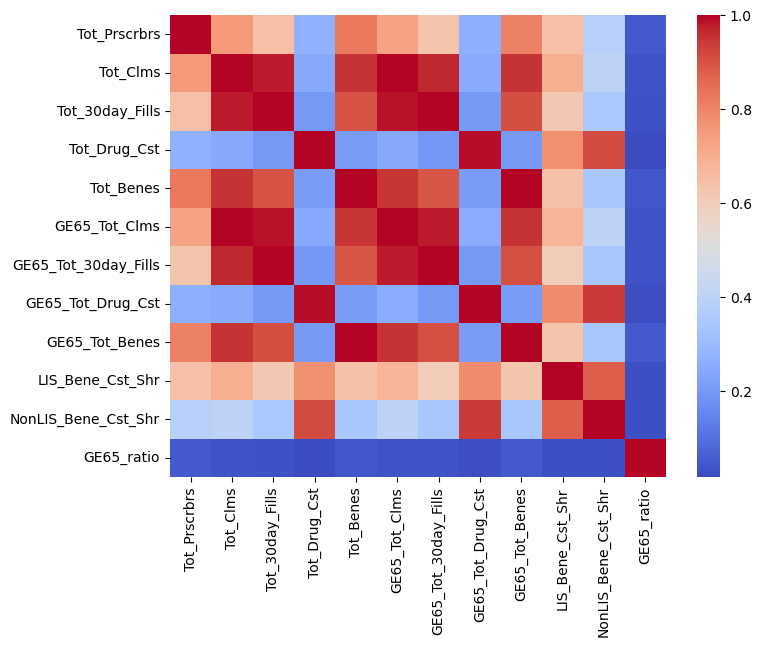

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

Let's analyze geography of claims:

In [26]:
df["Prscrbr_Geo_Lvl"].value_counts()

Prscrbr_Geo_Lvl
State       112329
National      3607
Name: count, dtype: int64

In [27]:
state_df = df[df["Prscrbr_Geo_Lvl"] == "State"] \
    .groupby("Prscrbr_Geo_Desc") \
    .agg({
        "Tot_Drug_Cst": "sum",
        "Tot_Clms": "sum"
    }).reset_index()

state_df["Cost_per_Claim"] = state_df["Tot_Drug_Cst"] / state_df["Tot_Clms"]

In [29]:
state_df["Cost_per_Claim"].describe()
state_df.sort_values("Cost_per_Claim", ascending=False).head()

,Prscrbr_Geo_Desc,Tot_Drug_Cst,Tot_Clms,Cost_per_Claim
12,District of Columbia,6.242542e+08,2215717,281.739128
38,New York,2.246829e+10,105560494,212.847513
1,Alaska,3.858098e+08,1826762,211.198744
10,Connecticut,3.952207e+09,18714564,211.183512
17,Hawaii,9.221600e+08,4428848,208.216667


In [32]:
state_brand = df[df["Prscrbr_Geo_Lvl"] == "State"] \
    .groupby(["Prscrbr_Geo_Desc", "Is_Brand"])["Cost_per_Claim"] \
    .mean().reset_index()

In [33]:
state_df["Cost_per_Claim"].describe()

count     61.000000
mean     156.456300
std       41.540543
min       11.756429
25%      146.522186
50%      160.506874
75%      172.716065
max      281.739128
Name: Cost_per_Claim, dtype: float64

In [34]:
state_df[state_df["Prscrbr_Geo_Desc"] != "District of Columbia"]["Cost_per_Claim"].describe()


count     60.000000
mean     154.368253
std       38.527916
min       11.756429
25%      146.055440
50%      160.120506
75%      172.409776
max      212.847513
Name: Cost_per_Claim, dtype: float64

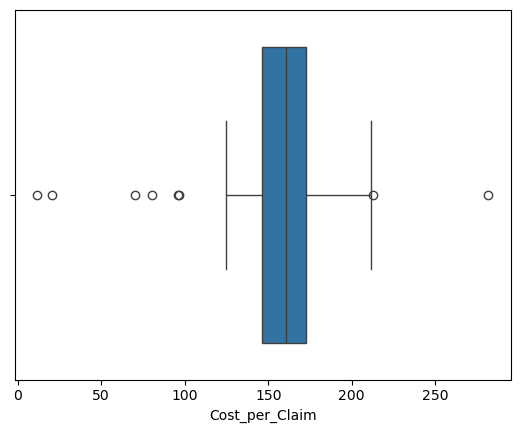

In [38]:
sns.boxplot(x=state_df["Cost_per_Claim"])
plt.show()

In [36]:
state_brand_weighted = df[df["Prscrbr_Geo_Lvl"] == "State"] \
    .groupby(["Prscrbr_Geo_Desc", "Is_Brand"]) \
    .agg({
        "Tot_Drug_Cst": "sum",
        "Tot_Clms": "sum"
    }).reset_index()

state_brand_weighted["Cost_per_Claim"] = \
    state_brand_weighted["Tot_Drug_Cst"] / state_brand_weighted["Tot_Clms"]

brand_pivot = state_brand_weighted.pivot(
    index="Prscrbr_Geo_Desc",
    columns="Is_Brand",
    values="Cost_per_Claim"
)

brand_pivot.columns = ["Generic", "Brand"]
brand_pivot["Brand_Premium"] = brand_pivot["Brand"] - brand_pivot["Generic"]

brand_pivot.sort_values("Brand_Premium", ascending=False).head()

,Generic,Brand,Brand_Premium
Prscrbr_Geo_Desc,,,
District of Columbia,38.459603,903.397128,864.937524
Connecticut,32.156364,705.980845,673.824481
Massachusetts,32.525379,683.274976,650.749596
Hawaii,34.994550,682.666943,647.672393
New York,35.875010,672.284608,636.409598


In [37]:
state_brand_weighted[state_brand_weighted["Prscrbr_Geo_Desc"] == "New York"]

,Prscrbr_Geo_Desc,Is_Brand,Tot_Drug_Cst,Tot_Clms,Cost_per_Claim
75,New York,False,2.733901e+09,76206278,35.875010
76,New York,True,1.973439e+10,29354216,672.284608
